(-0.5, 255.5, 255.5, -0.5)

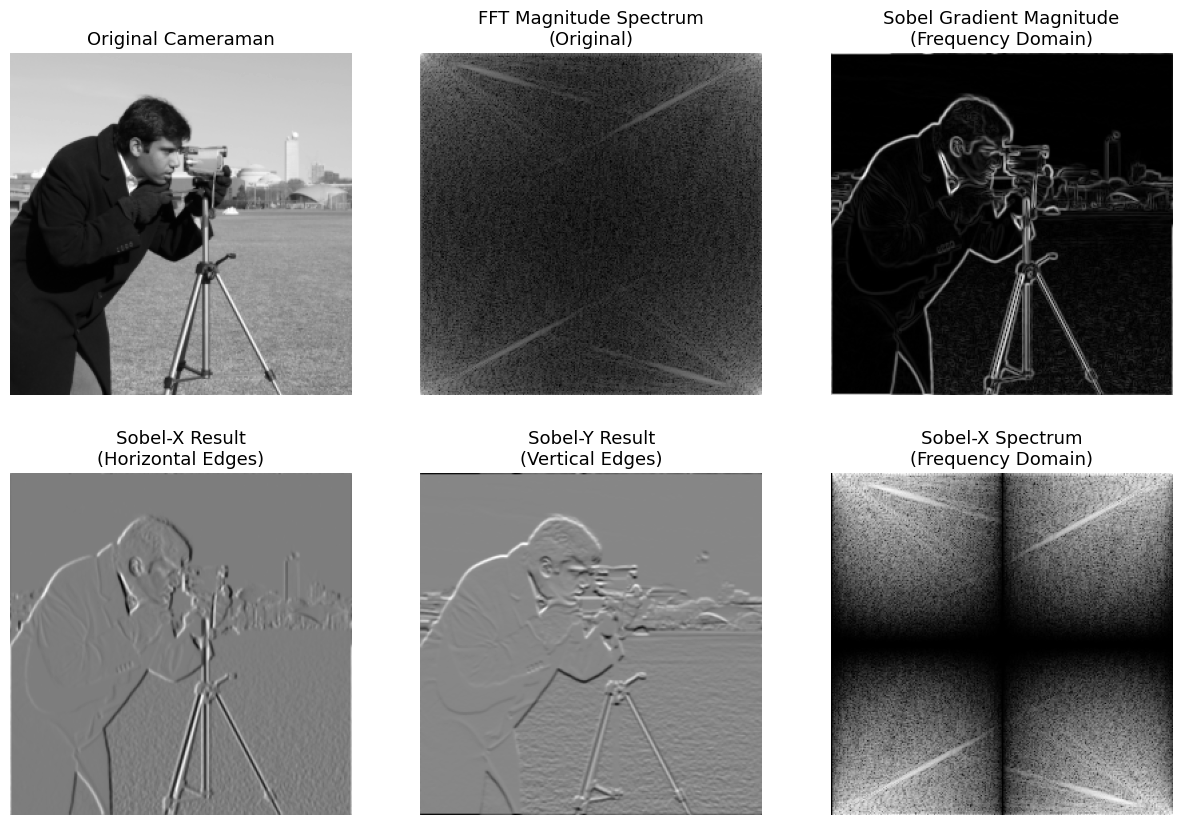

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

image = data.camera()
image = resize(image, (256, 256))  


sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])


def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2

    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded))  

F = np.fft.fft2(image)


H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)


F_sobel_x = F * H_x
F_sobel_y = F * H_y


sobel_x_result = np.fft.ifft2(F_sobel_x).real
sobel_y_result = np.fft.ifft2(F_sobel_y).real


sobel_magnitude = np.sqrt(sobel_x_result**2 + sobel_y_result**2)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Cameraman', fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(np.log(1 + np.abs(F)), cmap='gray')
axes[0, 1].set_title('FFT Magnitude Spectrum\n(Original)', fontsize=13)
axes[0, 1].axis('off')

axes[0, 2].imshow(sobel_magnitude, cmap='gray')
axes[0, 2].set_title('Sobel Gradient Magnitude\n(Frequency Domain)', fontsize=13)
axes[0, 2].axis('off')

axes[1, 0].imshow(sobel_x_result, cmap='gray')
axes[1, 0].set_title('Sobel-X Result\n(Horizontal Edges)', fontsize=13)
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_y_result, cmap='gray')
axes[1, 1].set_title('Sobel-Y Result\n(Vertical Edges)', fontsize=13)
axes[1, 1].axis('off')

axes[1, 2].imshow(np.log(1 + np.abs(F_sobel_x)), cmap='gray')
axes[1, 2].set_title('Sobel-X Spectrum\n(Frequency Domain)', fontsize=13)
axes[1, 2].axis('off')

